Isaac Noe

9/13/26

Block 1 Checkpoint: "Choose Your Oscillator"

In [1]:
import numpy as np
import matplotlib.pyplot as plt

1. Choose a system that oscillates (or could oscillate). It can be from Taylor, from your own experience, or from a physics curiosity.

A bungee jummper weighing 70 kg jumps off of a bridge for 20 seconds with a 10 m long rope with a spring constant of 120 N/m.

2. Implement the simulation in a Jupyter notebook using Euler-Cromer (AI can help you to produce a well-structured simulation)

In [2]:
# Parameters
m = 70.0
g = 9.81
L = 10.0
k = 120.0
dt = 0.001
t_end = 20.0

def simulate_bungee(m, g, L, k, dt, t_end):
    t = np.arange(0, t_end + dt, dt)
    x = np.zeros_like(t)  # downward position
    v = np.zeros_like(t)

    for i in range(len(t) - 1):
        extension = max(x[i] - L, 0.0)
        acc = g - (k / m) * extension

        # Euler-Cromer update
        v[i + 1] = v[i] + acc * dt
        x[i + 1] = x[i] + v[i + 1] * dt

    extension = np.maximum(x - L, 0.0)
    ke = 0.5 * m * v**2
    grav_e = -m * g * x
    spring_e = 0.5 * k * extension**2
    total_e = ke + grav_e + spring_e

    return t, x, v, ke, grav_e, spring_e, total_e

t, x, v, ke, grav_e, spring_e, total_e = (simulate_bungee(m, g, L, k, dt, t_end))

3. Validate with at least two methods from your toolkit: energy tracking, convergence test, comparison to an exact solution (if one exists), symmetry check, or work-energy theorem

In [3]:
# Exact position solution
t_taut = np.sqrt(2 * L / g)
omega = np.sqrt(k / m)
x_eq = L + m * g / k
v_taut = g * t_taut

x_ex = np.zeros_like(t)
v_ex = np.zeros_like(t)

free_fall = t <= t_taut
taut = ~free_fall

x_ex[free_fall] = 0.5 * g * t[free_fall]**2
v_ex[free_fall] = g * t[free_fall]

tau = t[taut] - t_taut
q0 = L - x_eq

x_ex[taut] = (x_eq + q0 * np.cos(omega * tau) + (v_taut / omega) * np.sin(omega * tau))
v_ex[taut] = (-q0 * omega * np.sin(omega * tau) + v_taut * np.cos(omega * tau))

In [4]:
# Exact energy over time
exact_extension = np.maximum(x_ex - L, 0.0)

ex_ke = 0.5 * m * v_ex**2
ex_grav = -m * g * x_ex
ex_spring = 0.5 * k * exact_extension**2

exact_total_energy = (ex_ke + ex_grav + ex_spring)

4. Present your results

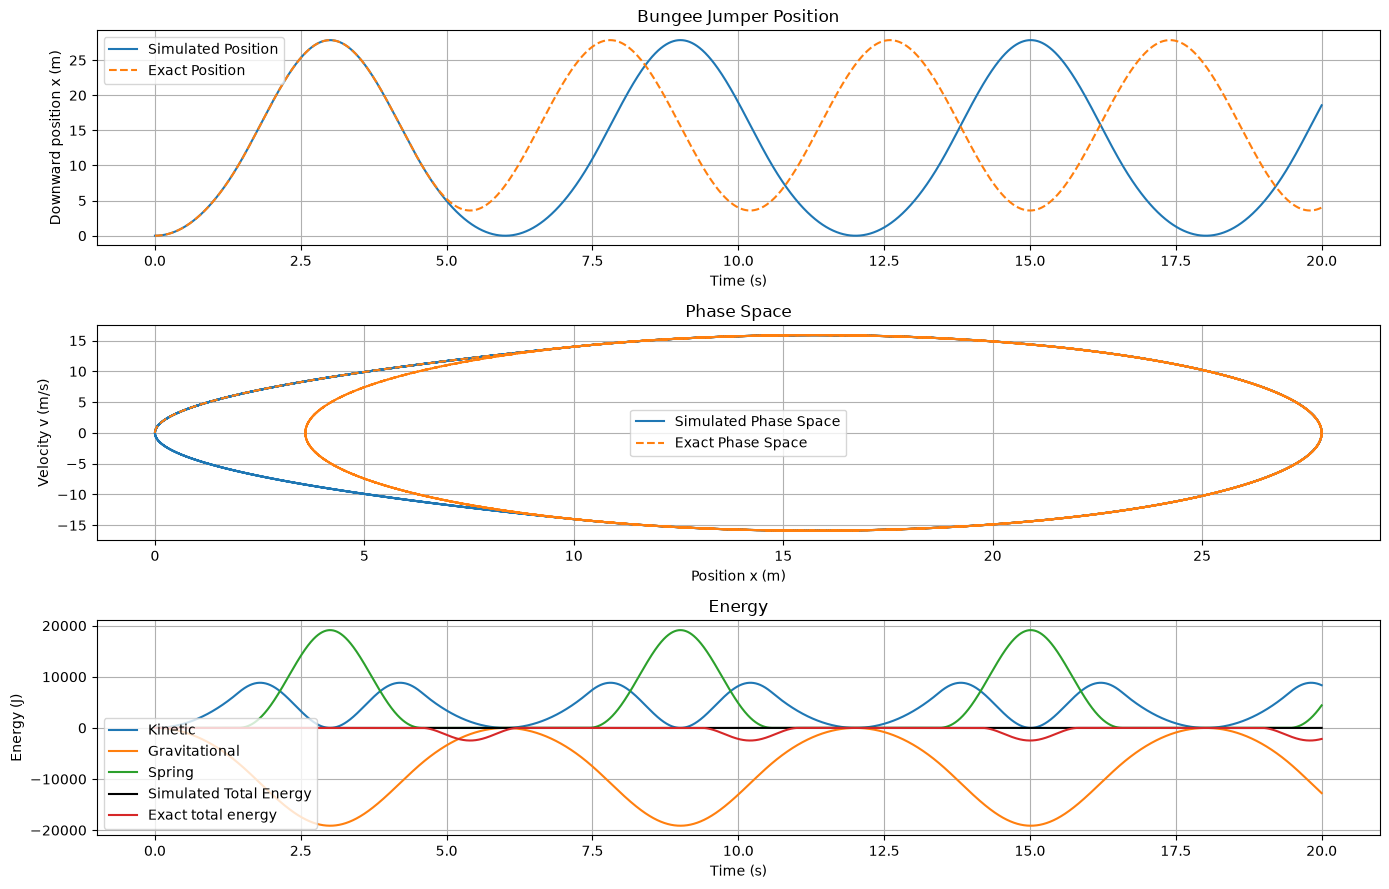

In [5]:
# Plots
fig, axes = plt.subplots(3, figsize=(14, 9))

# x(t) plot
axes[0].plot(t, x, label = "Simulated Position", linewidth = 1.5)
axes[0].plot(t, x_ex, "--", label = "Exact Position")
axes[0].set_title("Bungee Jumper Position")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Downward position x (m)")
axes[0].legend()
axes[0].grid()

# Phase space plot
axes[1].plot(x, v, label = "Simulated Phase Space", linewidth = 1.5)
axes[1].plot(x_ex, v_ex, "--", label = "Exact Phase Space")
axes[1].set_title("Phase Space")
axes[1].set_xlabel("Position x (m)")
axes[1].set_ylabel("Velocity v (m/s)")
axes[1].legend()
axes[1].grid()

# Energy plot
axes[2].plot(t, ke, label = "Kinetic")
axes[2].plot(t, grav_e, label = "Gravitational")
axes[2].plot(t, spring_e, label = "Spring")
axes[2].plot(t, total_e, "k", label = "Simulated Total Energy")
axes[2].plot(t, exact_total_energy, label="Exact total energy")
axes[2].set_title("Energy")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Energy (J)")
axes[2].legend()
axes[2].grid()

plt.tight_layout()
plt.show()

A brief written explanation of what the system is, what the physics predicts, and whether your simulation agrees.

The simulation is of a person bungee jumping. The person weighs 70 kg and he is using a 10 meter long rope to jump. The rope has a spring constant of 120 Newtons per meter. The physics predicts that if he is in a frictionless environment that he will oscillate between 0 and 27 meters with down as a positive direction. The simulation also predicts this. However, the exact solution predicts a different period than the simulation. It can also be noted that the left side of the simulated phase space plot has been offset from the exact phase space by 4 meters. In the Energy plot, it can be seen that the simulated energy does not match the exact energy. The exact energy shows a small dip in its line, which would mean at some point its energy is not conserved. This is the opposite of what the simulation says. The simulation shows the total energy to be constant throughout the simulation. Therefore, it can be surmised that the physics and the simulation do not agree with each other.